In [2]:
import os
import numpy as np
from PIL import Image
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random

In [52]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Image transform (resize and grayscale)
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [54]:
train_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/train/", transform=transform)
test_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/test/", transform=transform)

In [56]:
def dataset_to_numpy(dataset):
    X = []
    y = []
    for img, label in dataset:
        X.append(img.view(-1).numpy())  # flatten
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)
class_labels = train_dataset.classes 

In [57]:
class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict(self, X):
        y_pred = []
        for x in X:
            distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
            y_pred.append(most_common)
        return np.array(y_pred)


In [58]:
knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [59]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7784


In [60]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))


Confusion Matrix:
 [[286  18]
 [ 66   9]]

Classification Report:
               precision    recall  f1-score   support

         ben       0.81      0.94      0.87       304
         mel       0.33      0.12      0.18        75

    accuracy                           0.78       379
   macro avg       0.57      0.53      0.52       379
weighted avg       0.72      0.78      0.73       379



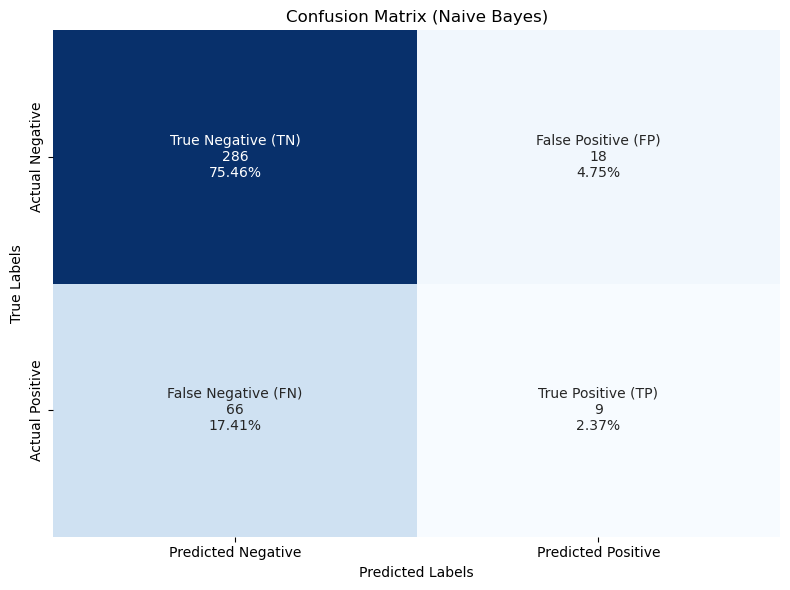


From Confusion Matrix:
Precision : 0.3333
Recall :    0.1200
F1 Score :  0.1765


In [61]:
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    group_names = ['True Negative (TN)', 'False Positive (FP)',
                   'False Negative (FN)', 'True Positive (TP)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

    labels = [f"{name}\n{count}\n{percent}" for name, count, percent in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, title="Confusion Matrix (Naive Bayes)")

def compute_metrics_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    return precision, recall, f1

# Calculate metrics
precision, recall, f1 = compute_metrics_from_cm(cm)
print(f"\nFrom Confusion Matrix:")
print(f"Precision : {precision:.4f}")
print(f"Recall :    {recall:.4f}")
print(f"F1 Score :  {f1:.4f}")
